# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [1]:
import math
import sys

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [5]:
# YOUR CODE HERE
dataset = pd.read_csv("deprecated_breast_cancer_wisconsin.tsv.gz", sep = "\t")

In [7]:
# Rename columns. 
dataset.columns = [
    "target",
    "radius1", "texture1", "perimeter1", "area1", "smoothness1",
    "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1",
    "radius2", "texture2", "perimeter2", "area2", "smoothness2",
    "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2",
    "radius3", "texture3", "perimeter3", "area3", "smoothness3",
    "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3"
]

In [9]:
dataset_10_rows_sample =  dataset.sample(n = 10 , random_state = 1234)

In [11]:
dataset_10_rows_sample

,target,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
531,0,11.670,20.02,75.21,416.2,0.10160,0.09453,0.04200,0.02157,0.1859,...,13.350,28.81,87.00,550.6,0.1550,0.29640,0.27580,0.08120,0.3206,0.08950
166,0,10.800,9.71,68.77,357.6,0.09594,0.05736,0.02531,0.01698,0.1381,...,11.600,12.02,73.66,414.0,0.1436,0.12570,0.10470,0.04603,0.2090,0.07699
485,0,12.450,16.41,82.85,476.7,0.09514,0.15110,0.15440,0.04846,0.2082,...,13.780,21.03,97.82,580.6,0.1175,0.40610,0.48960,0.13420,0.3231,0.10340
66,0,9.465,21.01,60.11,269.4,0.10440,0.07773,0.02172,0.01504,0.1717,...,10.410,31.56,67.03,330.7,0.1548,0.16640,0.09412,0.06517,0.2878,0.09211
220,0,13.650,13.16,87.88,568.9,0.09646,0.08711,0.03888,0.02563,0.1360,...,15.340,16.35,99.71,706.2,0.1311,0.24740,0.17590,0.08056,0.2380,0.08718
356,0,13.050,18.59,85.09,512.0,0.10820,0.13040,0.09603,0.05603,0.2035,...,14.190,24.85,94.22,591.2,0.1343,0.26580,0.25730,0.12580,0.3113,0.08317
414,1,15.130,29.81,96.71,719.5,0.08320,0.04605,0.04686,0.02739,0.1852,...,17.260,36.91,110.10,931.4,0.1148,0.09866,0.15470,0.06575,0.3233,0.06165
525,0,8.571,13.10,54.53,221.3,0.10360,0.07632,0.02565,0.01510,0.1678,...,9.473,18.45,63.30,275.6,0.1641,0.22350,0.17540,0.08512,0.2983,0.10490
77,1,18.050,16.15,120.20,1006.0,0.10650,0.21460,0.16840,0.10800,0.2152,...,22.390,18.91,150.10,1610.0,0.1478,0.56340,0.37860,0.21020,0.3751,0.11080
239,1,17.460,39.28,113.40,920.6,0.09812,0.12980,0.14170,0.08811,0.1809,...,22.510,44.87,141.20,1408.0,0.1365,0.37350,0.32410,0.20660,0.2853,0.08496


YOUR ANSWERS HERE

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [13]:
dataset.columns.to_numpy()

array(['target', 'radius1', 'texture1', 'perimeter1', 'area1',
       'smoothness1', 'compactness1', 'concavity1', 'concave_points1',
       'symmetry1', 'fractal_dimension1', 'radius2', 'texture2',
       'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2',
       'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3',
       'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3',
       'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3'],
      dtype=object)

YOUR ANSWERS HERE

1) Target : "1" for maglinant and "0" for benign
2) Radius1 :  The average distance from the center to points on the perimeter (measures the size of the nucleous)
3) Texture1  : It measures the standard deviation of gray-scale, reflecting how visually heterogenous the nucleus looks in the image
4) Area1 : It measures the average area of the nucleus
5) smoothess1 : it measures the local variation in radius weight, describing how regular or irregular the contour is
6) compactedness1 : defined as perimeter^2 / area - 1.0, how compact vs spread the shape ois
7) concavity1:  It measures the severity of concave portions of the contour,  useful for describing shape deformation
8) concave_points1: It measures the number of concave portions of the contour, useful as it captrues boundary complexity.
9) symetry1: It measures how symetric thbe nucleus shape is
10) fractal_dimensional1: it measures how fine boundary irrugalarity is. 

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

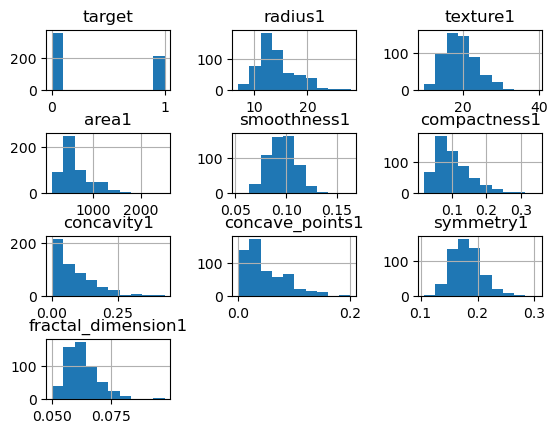

In [23]:
# YOUR CODE HERE
columns_10 = ['target','radius1','texture1','area1','smoothness1','compactness1','concavity1','concave_points1','symmetry1','fractal_dimension1']

pd.plotting.hist_frame(dataset[columns_10 ])
plt.subplots_adjust(wspace = 0.5,hspace = 0.7)
None


YOUR ANSWERS HERE

During the module, we covered Bernoulli, Bionomial, Gaussian and Beta 
During the module, we covered Bernoulli, Binomial, Gaussian, and Beta distributions.

| Variable | Distribution |
|---|---|
| target | Bernoulli |
| radius1 | Approximately Gaussian |
| texture1 | Approximately Gaussian |
| area1 | Approximately Gaussian |
| smoothness1 | Approximately Gaussian |
| compactness1 | Beta-like |
| concavity1 | Beta-like |
| concave_points1 | Beta-like |
| symmetry1 | Approximately Gaussian |
| fractal_dimension1 | Approximately Gaussian |


### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

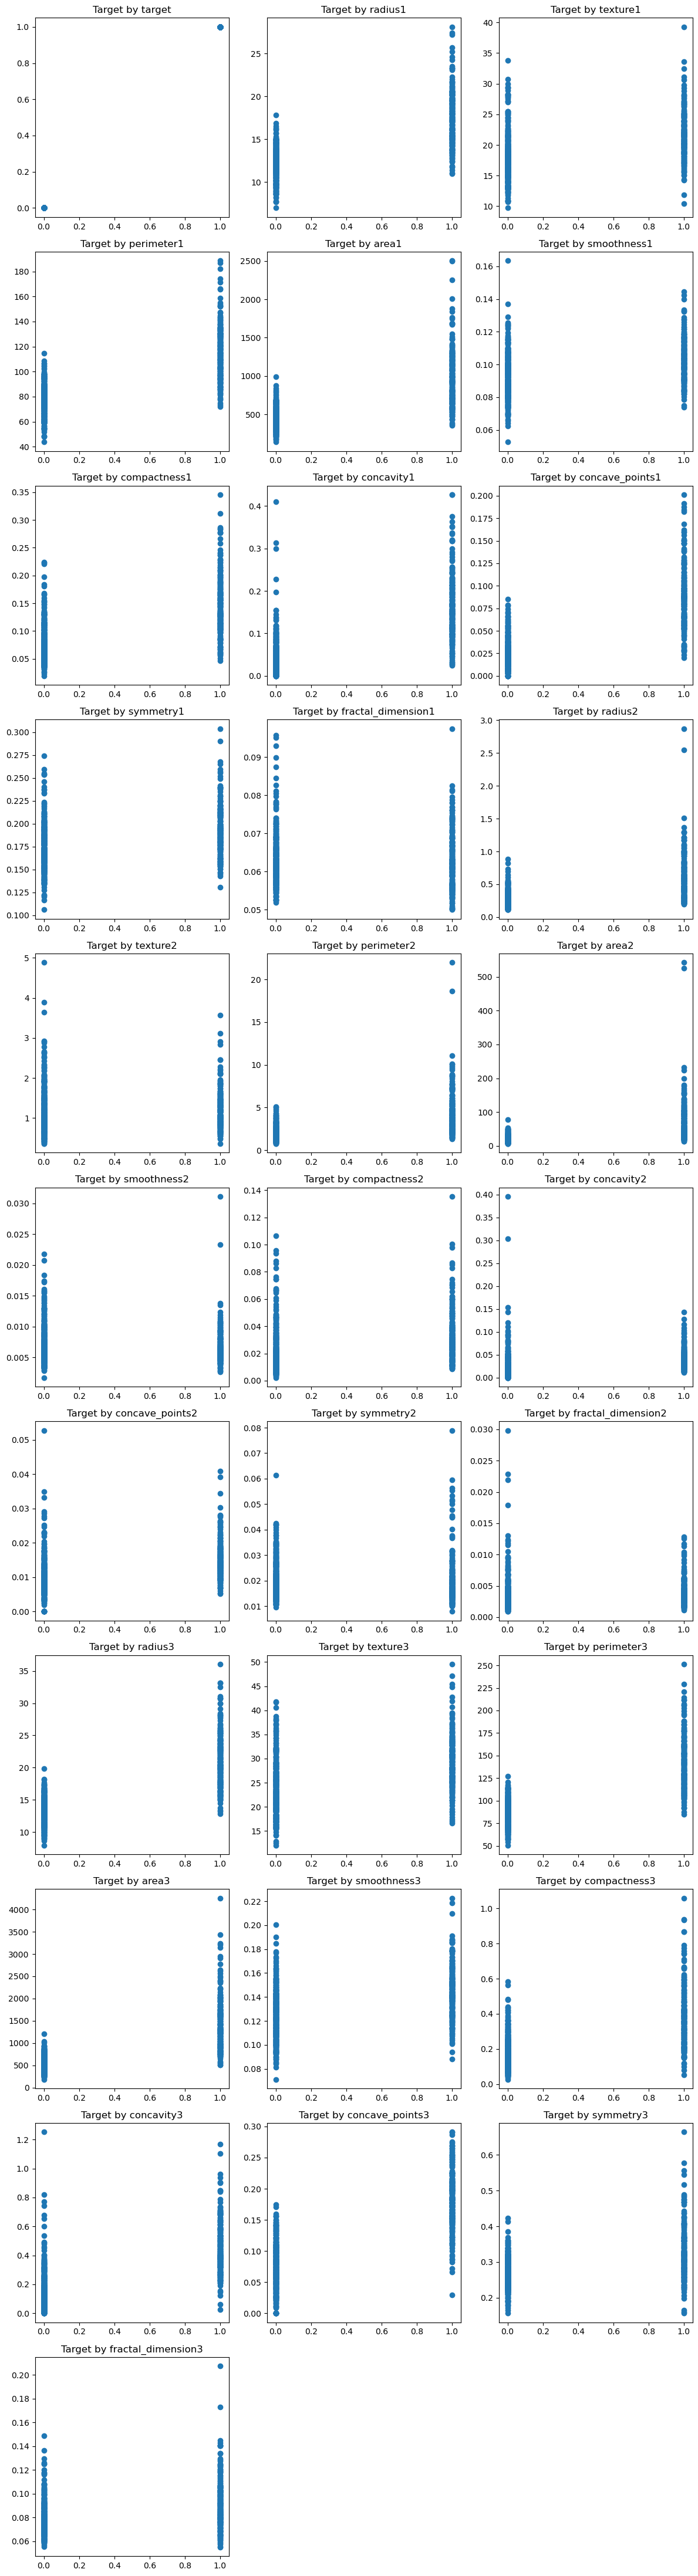

In [35]:
# YOUR CODE HERE

#columns_10 = ['concave_points3','perimeter3','concave_points1','radius3','perimeter1','area3',
 #   'radius1','area1','concavity1','concavity3']

columns = dataset.columns

n = len(columns_10) ## sample of 10 columns

cols = 3  #  For this excercise I want 3 columns.
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for i, c in enumerate(columns_10):
    ax = axes[i]
    ax.scatter(dataset['target'],dataset[c])
    ax.set_title(f'Target by {c}')

# remove the remainig 
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

YOUR ANSWERS HERE

In this case, as our target variable is a bionomial, the easiest way to identify dependendy or independecy is by plotting a scatter plot  between the target and the feature.

**Independence**: In this case, there should not be a significant difference between the values of the feature classified by target, in other words, the scatter plot should be within  the same range of y-axis  regardless of  the points  classified either "1" or "0". Impliying that the feature values are not   significantly associated with the  classification of the target.

**Dependency**: in this case, there is an observable difference, where the distributions of values classified either "1" or "0" differ in the y -axis range, implying that the target is different depending on the values presented in the feature. 

**Variables showing high dependency** : radius1, perimeter1,area1,concave_points1,radius3,perimeter3,area3 & area3.    

**Variables showing independence**: radius1, perimeter1, area1, concave_points1, radius3, perimeter3, area3, and concave_points3

**Conclusion**
These results show that features related to the  size of the tumors are more meaningful to detect the malignancy or benignity of the tumor, while the features related to textures, composition and shape (with the exeption of concave points) of tumors are not so clear to diferentiate a tumor whether it is malign or benign.  

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

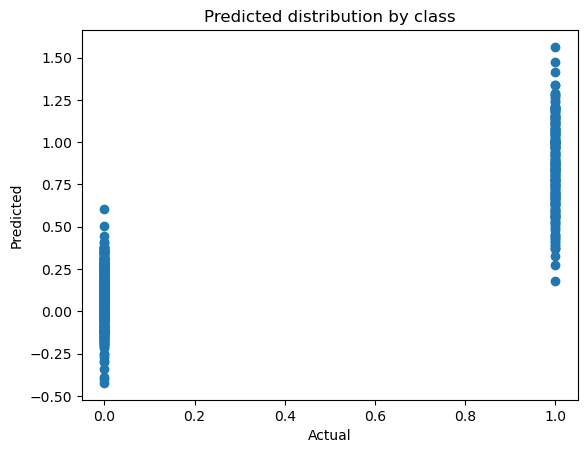

mse without threshold: 0.0527550044305191
rmse without threshold: 0.22968457595258568
r2 without threshold: 0.7743246526421794


In [48]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
model_l = LinearRegression()
target = dataset["target"]
features_t = dataset.copy().drop(columns='target') # total features 
features_s = dataset[columns_10].copy().drop(columns='target') # a sampole of  features 


model_l.fit(features_t,target)
target_pre = model_l.predict(features_t)
mse = ((target-target_pre)**2).mean()
rmse = np.sqrt(mse) 

# scatter plot
plt.scatter(target,target_pre)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted distribution by class")
plt.show()

# r2 calculation
ss_res = np.sum((target - target_pre) ** 2)
ss_tot = np.sum((target - np.mean(target)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# printing resultus 
print(f'mse without threshold: {mse}')
print(f'rmse without threshold: {rmse}')
print(f'r2 without threshold: {r2}')



Best threshold: 0.38
Best accuracy: 0.9806678383128296


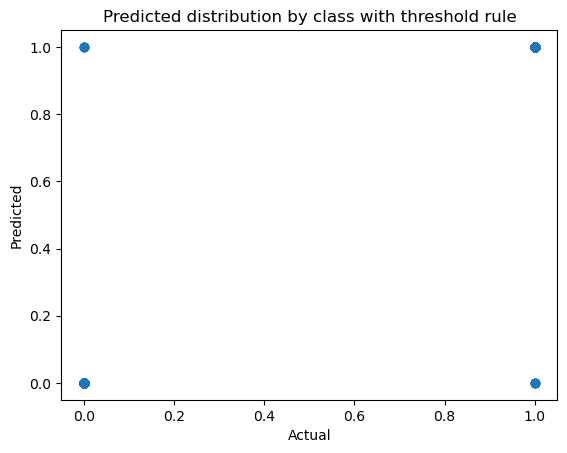

mse with threshold: 0.019332161687170474
rmse with threshold: 0.1390401441568962
r2 with threshold: 0.9173008826171978


In [50]:
# Additional analysis by adjusting a threshold to simulate a "classification"
model_l = LinearRegression()
target = dataset["target"]
features_t = dataset.copy().drop(columns='target') # total features 
features_s = dataset[columns_10].copy().drop(columns='target') # sample features

model_l.fit(features_t,target)
target_pre = model_l.predict(features_t)


## best threshold iterations 
thresholds = np.arange(0.0, 1.01, 0.01)

best_threshold = 0
best_accuracy = 0

for t in thresholds:
    y_pred_t = (target_pre >= t).astype(int)   # aquí y_pred puede ser tu OLS prediction
    acc = (y_pred_t == target).sum() / len(target)

    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best accuracy:", best_accuracy)



#graph with new threshold 
target_pre_class = (target_pre >= 0.38).astype(int) 
plt.scatter(target,target_pre_class)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted distribution by class with threshold rule")
plt.show()

mse = ((target-target_pre_class)**2).mean()
rmse = np.sqrt(mse)

ss_res = np.sum((target - target_pre_class) ** 2)
ss_tot = np.sum((target - np.mean(target)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f'mse with threshold: {mse}')
print(f'rmse with threshold: {rmse}')
print(f'r2 with threshold: {r2}')

It's worth clarifying that by using a linear regression, the predicted values are a range of continous outputs rather than a classification,however, when plotting predicted values vs real values I was able to visualize a separation trend somewhere between 0.25 and 0.5 where values were more concentrated, that's why I decided to find a threshold by iterations that maximizes the accuracy as a complementary analysis, interestingly, by applying the threshold, the accuaracy reached 0.98 and mse around 0.019. 

Even without applying the threshold, there was a clear  tendency :  observations with  an actual  value of  1.0 , generally had higher predicted values than observation with an actual value of 0.0. 


### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [51]:
# YOUR CODE HERE

model_l = LinearRegression()
target = dataset["target"]

models = {} # create a dictionary 

# Loop to store all the models with columnms 
for c in dataset.columns:    
    model_l.fit(dataset[[c]],target)
    target_pre = model_l.predict(dataset[[c]])
    errors = target - target_pre
    mse = np.mean(errors**2)
    rmse = np.sqrt(mse)
    
    ss_res = np.sum((target - target_pre) ** 2)
    ss_tot = np.sum((target - np.mean(target)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    models[c] = [mse,rmse,r2]

# convert dictionary into dataframe and find the columum with best MSE

df = pd.DataFrame(models)
df = df.T
df.columns = ["MSE", "RMSE", "R2"]
df_sorted = df.sort_values(by=["MSE", "RMSE", "R2"], ascending=[True, True, False])
df_sorted


,MSE,RMSE,R2
target,1.395064e-30,1.181128e-15,1.000000
concave_points3,8.655220e-02,2.941975e-01,0.629747
perimeter3,9.047769e-02,3.007951e-01,0.612955
concave_points1,9.277455e-02,3.045891e-01,0.603129
radius3,9.283266e-02,3.046845e-01,0.602880
perimeter1,1.048419e-01,3.237929e-01,0.551508
area3,1.078828e-01,3.284551e-01,0.538499
radius1,1.091819e-01,3.304269e-01,0.532942
area1,1.162611e-01,3.409709e-01,0.502658
concavity1,1.204084e-01,3.469992e-01,0.484917


In [60]:
# linear regression with concave_points 3- 
model_l = LinearRegression()
target = dataset["target"]
feature = dataset[["concave_points3"]] 

model_l.fit(feature,target)
target_pre = model_l.predict(feature)
errors = target - target_pre
mse = np.mean(errors**2)
rmse = np.sqrt(mse)

ss_res = np.sum((target - target_pre) ** 2)
ss_tot = np.sum((target - np.mean(target)) ** 2)
r2 = 1 - (ss_res / ss_tot)


print(f'mse with threshold: {mse}')
print(f'rmse with threshold: {rmse}')
print(f'r2 with threshold: {r2}')


mse with threshold: 0.08655219828445855
rmse with threshold: 0.2941975497594406
r2 with threshold: 0.6297470235614584


**Your Answer**

In this case, the model with just one column is underperforming vs the model which includes all the columns, our mse increased from 0.052 to 0.086, rmse also had the same trend moving from 0.22 to 0.29 while  r2 diminished from 0.77 to 0.63, suggesting that the combination of all variables provides more predictive information rather than one varialbe. 

However, it is also worth mentioning that there is a trade-off of good performance and simplicty, since the concave_points3 might be useful to build a simple model without requiring too much information, nevertheless, this simplicity comes at the cost of lower predictive performance. 

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

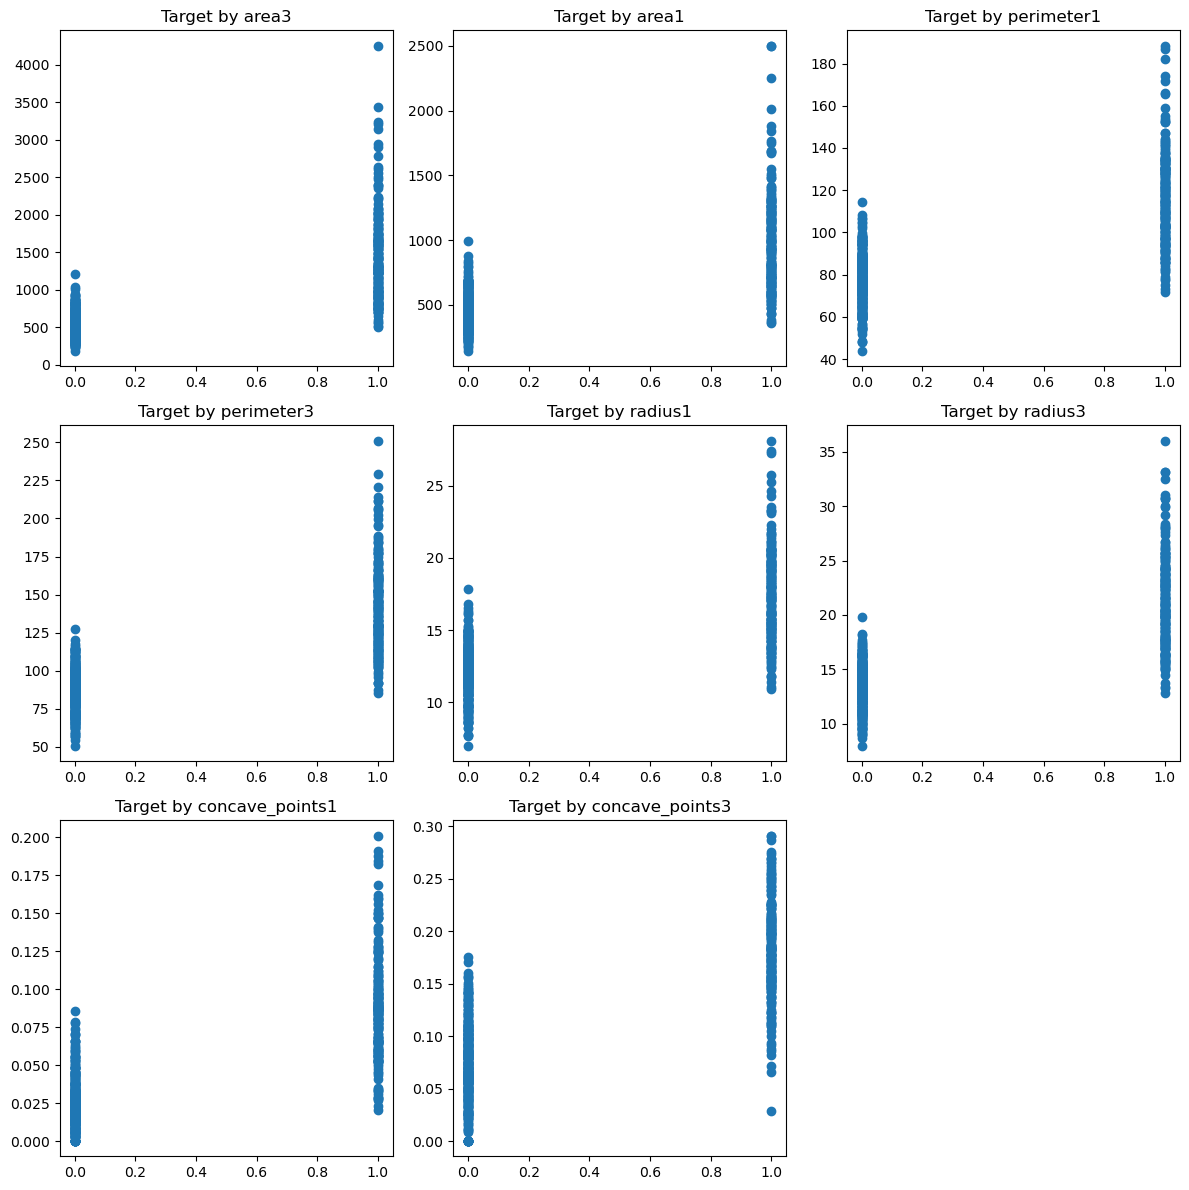

In [65]:
# YOUR CODE HERE

columns_selected = ['area3','area1','perimeter1','perimeter3','radius1','radius3','concave_points1',
    'concave_points3']

n = len(columns_selected) ## sample of 10 columns

cols = 3  #  For this excercise I want 3 columns.
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for i, c in enumerate(columns_selected):
    ax = axes[i]
    ax.scatter(dataset['target'],dataset[c])
    ax.set_title(f'Target by {c}')

# remove the remainig 
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [171]:
## best threshold function to find the optimal threshold.
def threshold(dataframe,target):
    thresholds = np.linspace(dataframe.min(), dataframe.max(), 100)
    
    best_threshold = [0]
    best_accuracy = 0
    
    for t in thresholds:
        prediction = (dataframe >= t).astype(int)   # aquí y_pred puede ser tu OLS prediction
        acc = (prediction == target).sum() / len(target)
    
        if acc > best_accuracy:
            best_accuracy = acc
            best_threshold[0] = t
    
    return best_threshold

In [173]:
#Creating dataframe with the corresponding threshold. 
results= {col : threshold(dataset[col],dataset["target"]) for col in columns_selected}
df = pd.DataFrame(results).T
df.columns = ["Threshold"]
df

,Threshold
area3,883.882828
area1,691.202020
perimeter1,96.411818
perimeter3,107.199091
radius1,15.091121
radius2,0.418333
concave_points1,0.050808
concave_points3,0.144030


In [73]:
#Create function to plot the grahphs
def hist(c, t):
    histo1_v = dataset[dataset[c] > t]
    histo2_v = dataset[dataset[c] <= t]
    
    fig, axs = plt.subplots(1, 2, sharex=True, tight_layout=True)
    
    axs[0].hist(histo1_v["target"], bins=[-0.5, 0.5, 1.5])
    axs[0].set_title(f'{c} > {t:.3f}')
    axs[0].set_xticks([0, 1])
    
    axs[1].hist(histo2_v["target"], bins=[-0.5, 0.5, 1.5])
    axs[1].set_title(f'{c} <= {t:.3f}')
    axs[1].set_xticks([0, 1])
    
    plt.show()

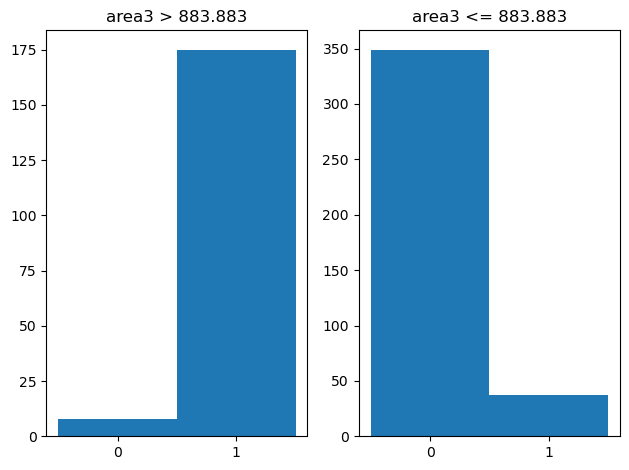

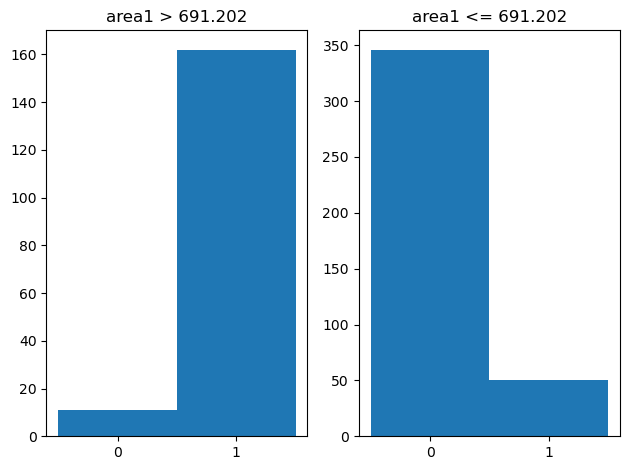

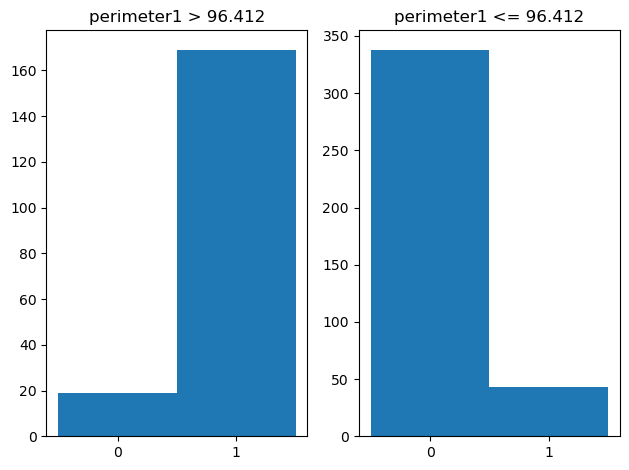

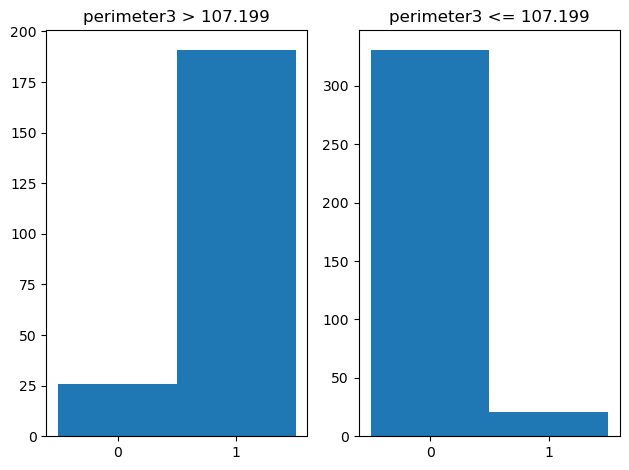

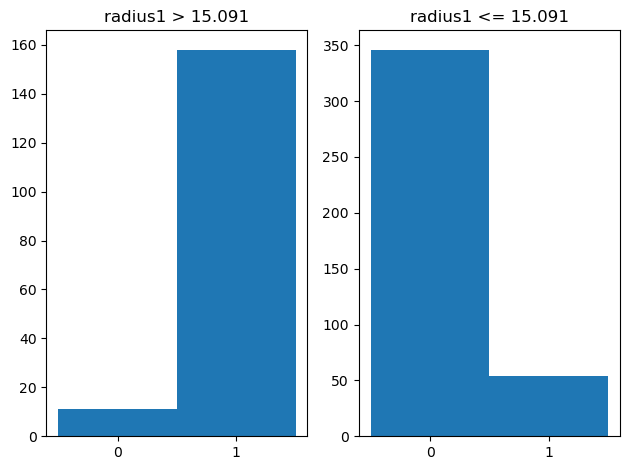

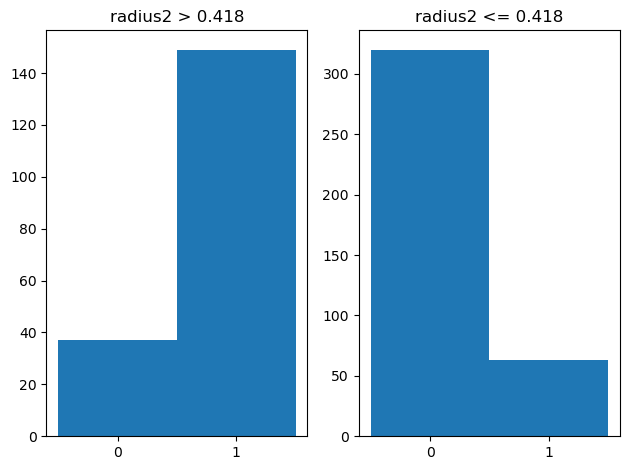

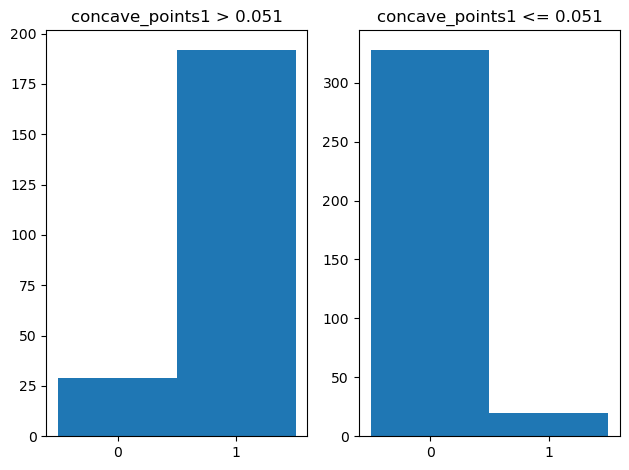

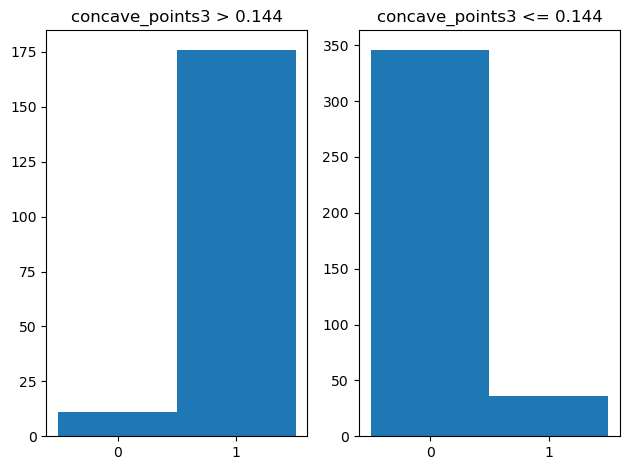

In [197]:
#loop for showing the graphs with thresohold
for index,row in df.iterrows():
    col = row["Threshold"]
    hist(index,col)

**YOUR ANSWERS HERE**

In this analysis, a threshold was selected based on accuracy. By applying this threshold to area3, the two histograms show clearly opposite trends, which illustrates a visible dependency between area3 and the target variable.

For example, when area3 is less than or equal to 883.883, the vast majority of observations are classified as 0. However, when area3 is greater than 883.883, the majority of observations are classified as 1. This suggests that the target distribution changes significantly depending on whether area3 is below or above the threshold.

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

first half variation explained : 98.80000000000001


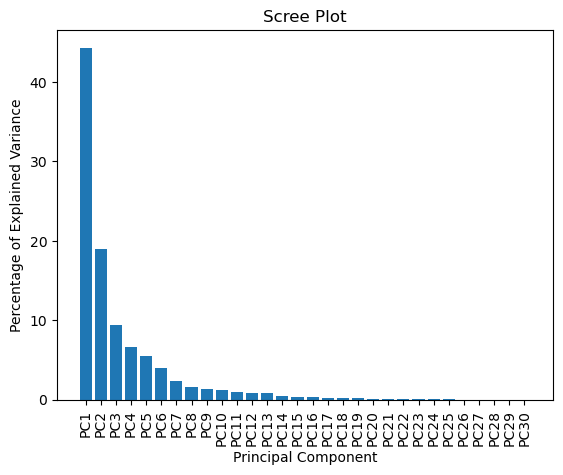

first 5 components variation explained : 84.8


In [281]:
# Principal component analysis 
pca_columns = [c for c in dataset.columns]

#scaling data 
dataset_scale = dataset.copy().drop(columns=["target"])
for col in dataset_scale.columns:
    dataset_scale[col] = (dataset[col]- dataset[col].mean())/(dataset[col].std())
    
# import the model
pca = PCA()
pca.fit(dataset_scale)
pca_data = pca.transform(dataset_scale)


per_var = np.round(pca.explained_variance_ratio_*100,decimals =1) 
labels = ["PC" +str(i) for i in range(1,len(per_var)+1)]


# explenation of the first half 
first_half = len(per_var)//2
variation_first_half = per_var[0:first_half].sum()
print(f'first half variation explained : {variation_first_half}')

#graph explenation

plt.bar(x = range(1,len(per_var)+1), height = per_var, tick_label = labels)
plt.xticks(rotation=90)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title("Scree Plot")
plt.show()
#variation of the first 5 components: 
print(f'first 5 components variation explained : {per_var[0:5].sum()}')


0.05986371045523042


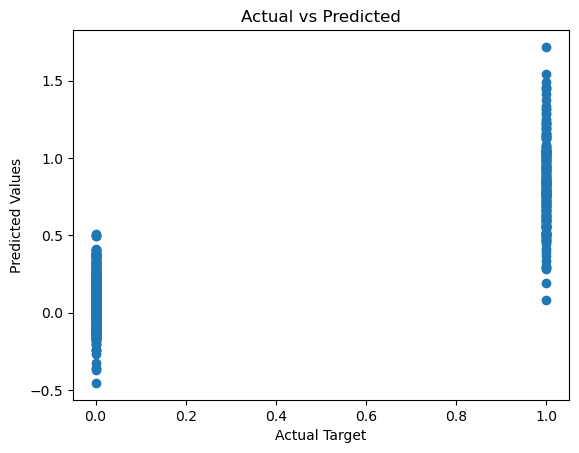

In [272]:
#Linear Regression Model first half: 
model_l = LinearRegression() 

target = dataset["target"]
model_l.fit(pca_data[:,:15],target)
target_pre = model_l.predict(pca_data[:,:15])
mse = ((target-target_pre)**2).mean()    

print(mse)
plt.scatter(target, target_pre)
plt.xlabel("Actual Target")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

0.0687828503528174


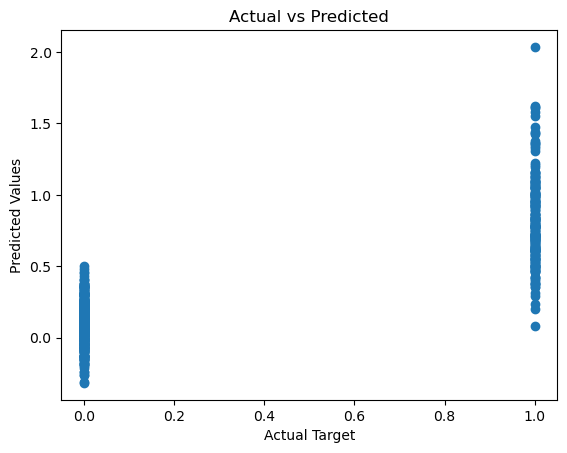

In [276]:
#Linear Regression Model first 5 components: 
model_l = LinearRegression() 

target = dataset["target"]
model_l.fit(pca_data[:,:5],target)
target_pre = model_l.predict(pca_data[:,:5])
mse = ((target-target_pre)**2).mean()    

print(mse)
plt.scatter(target, target_pre)
plt.xlabel("Actual Target")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

**YOUR ANSWERS HERE**

For this case, by applying the principal component analysis, the first half explained alomost 98.8% of the variance, however, only the first 5 components could explained almost 85% of the variation. 

By applying a linear model regression, our mse reached 0.0598 compared to 0.0527 (variation around 13%)  in the first model ( using all columns). In this case, the variable reduction only increased by a minimal amount the mse, evidencing  that even with half of the variables, the model can still  producing  comparable predictive performance  as using all the variables.

I tried to use as a complementary analysis  a linear regression with only 5 components, as these were able to explained almost 85% of the varition, however, the mse worsened from 0.0527 to 0.068 ( +28%),  although  the model reduced the variables by 83%.

When using the rmse insted of mse, our first model without the threshold analysis exhibits a 0.23, suggesting that our models deviates  in almost 0.23 units  from the true value, with half of the components this indicator is 0.25 and with only 5 components just 0.26, this suggest that by reducing more than 83% of the variables our model has a slightly variation in its predictive performance. 

This kind of behaviour is consistent with the fact that the target variable is binary,  while linear regression produces continous outputs, that´s why when using the threslgold analysis in the problem 5, our mse was only 0.019 and rmse 0.14. Suggesting that classifciation models such as Decision Trees or Logistic Regression could be more suitable for this type of problem.

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [88]:
# YOUR CODE HERE
# Correlation Matrix
corr = dataset.corr(numeric_only=True)
#filter to groups with high correlation 
filter_corr = corr[((corr > 0.9) & (corr<1)) | ((corr > -0.9) & (corr<-1))  ]
#organizing the data
filter_corr  = filter_corr .unstack().dropna()
filter_corr

radius1          perimeter1         0.997855
                 area1              0.987357
                 radius3            0.969539
                 perimeter3         0.965137
                 area3              0.941082
texture1         texture3           0.912045
perimeter1       radius1            0.997855
                 area1              0.986507
                 radius3            0.969476
                 perimeter3         0.970387
                 area3              0.941550
area1            radius1            0.987357
                 perimeter1         0.986507
                 radius3            0.962746
                 perimeter3         0.959120
                 area3              0.959213
concavity1       concave_points1    0.921391
concave_points1  concavity1         0.921391
                 concave_points3    0.910155
radius2          perimeter2         0.972794
                 area2              0.951830
perimeter2       radius2            0.972794
          

In [329]:
#loadings weights in the first component
loadings = pd.Series(pca.components_[0], index=dataset_scale.columns)
loadings[["radius1", "perimeter1"]]

radius1       0.218902
perimeter1    0.227537
dtype: float64

In [331]:
#all loadings in the first component.
loadings

radius1               0.218902
texture1              0.103725
perimeter1            0.227537
area1                 0.220995
smoothness1           0.142590
compactness1          0.239285
concavity1            0.258400
concave_points1       0.260854
symmetry1             0.138167
fractal_dimension1    0.064363
radius2               0.205979
texture2              0.017428
perimeter2            0.211326
area2                 0.202870
smoothness2           0.014531
compactness2          0.170393
concavity2            0.153590
concave_points2       0.183417
symmetry2             0.042498
fractal_dimension2    0.102568
radius3               0.227997
texture3              0.104469
perimeter3            0.236640
area3                 0.224871
smoothness3           0.127953
compactness3          0.210096
concavity3            0.228768
concave_points3       0.250886
symmetry3             0.122905
fractal_dimension3    0.131784
dtype: float64

**YOUR ANSWERS HERE**

I chose Radio1 and Perimetro1 for this case. The fact that Radio1 and Perimetro1 are correlated means that they are not really necessary to have both. This is because Radio1 and Perimetro1 are giving us the same information.

The first principal component is giving importance to both Radio1 and Perimetro1. This makes sense because the principal component analysis puts correlated variables like Radio1 and Perimetro1 together.

The first principal component, which we can call PC1 is giving a lot of importance to variables, not just Radio1 and Perimetro1. So PC1 is not about one variable it is about a general pattern that we see across many variables that are related to each other, like the size and shape of a tumor.

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

In [91]:
# YOUR CODE HERE
# Calculating the Interquartile Range (IQR)
data_outliers = dataset.describe().T.copy()
data_outliers["IQR"] = data_outliers["75%"]-data_outliers["25%"]


In [93]:
#Defining upper & lower limits
data_outliers["low_lim"] = data_outliers["25%"] -1.5*data_outliers["IQR"]
data_outliers["upp_lim"] = data_outliers["75%"] +1.5*data_outliers["IQR"]

In [95]:
# transposing for looping
data_outliers = data_outliers.T

In [97]:
# Loop to calculate how many outliers per rows
row_outliers = {} 

for index, row in dataset.iterrows():
    outliers = 0
    for col in  dataset.columns:
        if (row[col] > data_outliers.loc["upp_lim",col]) or (row[col] < data_outliers.loc["low_lim",col]):
            outliers += 1
    row_outliers[index] = outliers

In [111]:
# Ranking of the rows with more outlierts per columns
row_outliers = dict(sorted(row_outliers.items(), key = lambda x : x[1],reverse = True))
print(list(row_outliers.items())[:10])

[(122, 18), (108, 17), (78, 13), (212, 13), (82, 12), (352, 12), (461, 12), (3, 11), (12, 10), (152, 10)]


In [103]:
# we select the column 122 as the row with higher outliers in the following columns:
outlier_columns = [] 
for col in dataset.columns: 
    if (dataset.loc[122,col] > data_outliers.loc["upp_lim",col]) or (dataset.loc[122,col ] < data_outliers.loc["low_lim",col]):
        outlier_columns.append(col)
outlier_columns

['radius1',
 'perimeter1',
 'area1',
 'smoothness1',
 'compactness1',
 'concavity1',
 'concave_points1',
 'symmetry1',
 'radius2',
 'texture2',
 'perimeter2',
 'area2',
 'smoothness2',
 'compactness2',
 'concavity2',
 'symmetry2',
 'fractal_dimension2',
 'area3']

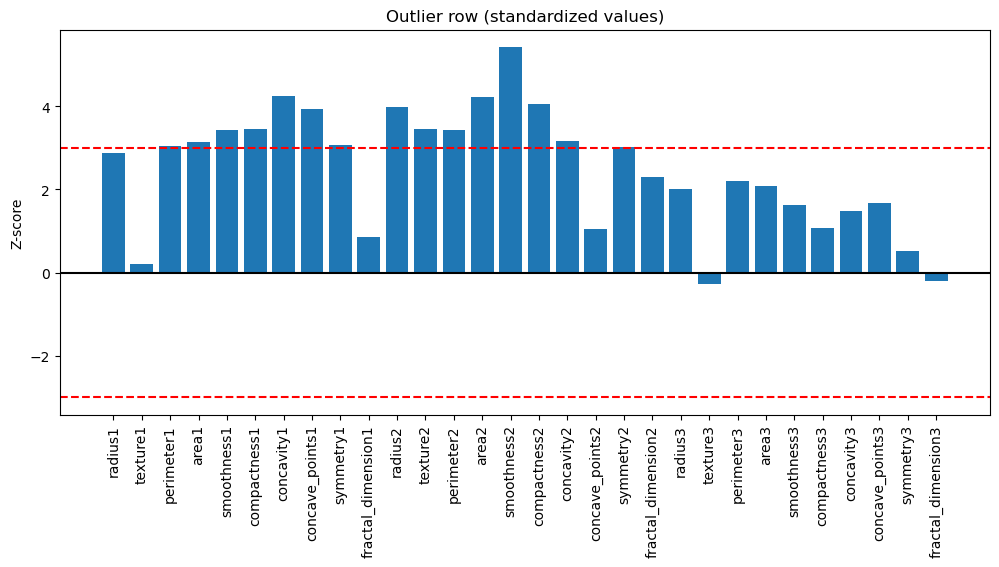

In [115]:
# Grapth 
features = dataset.drop(columns=["target"])

features_scaled = (X - X.mean()) / X.std()

row_scaled = features_scaled.loc[122]
plt.figure(figsize=(12,5))

plt.bar(X.columns, row_scaled)

plt.axhline(0, color="black")
plt.axhline(3, linestyle="--", color="red")
plt.axhline(-3, linestyle="--", color="red")

plt.xticks(rotation=90)
plt.ylabel("Z-score")
plt.title("Outlier row (standardized values)")
plt.show()


**YOUR ANSWERS HERE** 

For this exercise, I started with interquartile range  to define the upper and lower limits,once those limits were set, I proceeded to identify the rows with the highest  number of outliers, in this case, the row 122 was the one with 18 outliers out of the 30. 

for the graph, I used another  appraoch as plotting a graph with the interquartile logic was complex for me at this point, therefore , I plotted a bar chart considering limits +- 3 times standard deviation from the mean, resulting in almost 15 outliers. This approach resulted in lower outliers ( 15 vs 18) since using the distance from the mean with standard deviations is only applicable when all the variables behave as a normal distribution.  

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

**YOUR ANSWER HERE**

I used AI for this following points: 

1) creating the columns names easy from the original dataset
2) Finding the best metric to use in my exercise to calculate the threlhod, for this case , AI recommended accuracy metric
3) Creating the dotted lines in my Z-score graph